# assess_model_performance.ipynb

Yiren Shen, Feb 2025

This notebook evaluates the performance of a pre-trained VortexNet model from the framework using simulation data. The model weights and hyperparameters are loaded from a JSON file. HF and LF data is loaded from pickle files using the `MFData` class. The data is split into training and test sets, standardized, and key dataset statistics are summarized. A latent space clustering sample is provided. 

# Assess model performance from pre-trained model

In [7]:
import subprocess
import sys
import os
try:
    import torch_geometric
    print("torch_geometric is already installed.")
except ImportError:
    print("torch_geometric is not installed. Installing now...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "torch-geometric"])
    print("torch_geometric has been installed.")

import scipy
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F
from torch_geometric.data import Data
import pickle
from generateDeltawing import vehicle_setup, full_setup, point_analysis
import math
import pandas as pd
import json

VortexNet_path = '/home/yiren/Desktop/MF-VortexNet'
sys.path.append(VortexNet_path)
import VortexNet
from VortexNet.MFData import MFData

torch_geometric is already installed.


## Helper functions for plottings

In [8]:
def plot_field_distribution(VD, cp, title='Pressure Distribution', min=None, max=None, ax=None, cbar=False):
    # Ensure cp is a 1D array
    if cp.ndim > 1:
        cp = cp.squeeze(0)

    if min is None:
        vmin = np.min(cp)
    else:
        vmin = min

    if max is None:
        vmax = np.max(cp)
    else:
        vmax = max

    # If no axes are provided, create one
    if ax is None:
        fig, ax = plt.subplots()

    # Normalize the pressure coefficient values to the range [vmin, vmax]
    norm = plt.Normalize(vmin=vmin, vmax=vmax)
    cmap = plt.get_cmap('viridis')
    scalar_map = plt.cm.ScalarMappable(norm=norm, cmap=cmap)

    # Plot the panels and fill with cp data
    for i in range(len(VD.XA1)):
        x = [VD.XA1[i], VD.XB1[i], VD.XB2[i], VD.XA2[i], VD.XA1[i]]
        y = [VD.YA1[i], VD.YB1[i], VD.YB2[i], VD.YA2[i], VD.YA1[i]]

        # Get the color for the current pressure coefficient value
        cp_value = cp[i]
        color = scalar_map.to_rgba(cp_value)

        # Fill the panel with the corresponding cp value
        polygon = plt.Polygon(np.column_stack((x, y)), closed=True, facecolor=color, edgecolor=(0, 0, 0, 0.1))
        ax.add_patch(polygon)

    ax.set_title(title)
    ax.set_xlabel('X [m]')
    ax.set_ylabel('Y [m]')
    ax.axis('equal')

    # Return the scalar map for consistent color bar
    if cbar:
        return scalar_map
    return None


# specify the model to import 

Choose the best model from Optuna

In [9]:
weights_name = '20241116_045918'

# Specify the path to the trained weights file
weights_path = "../pretrained_model/model_weights_{}.pth".format(weights_name)
print(weights_path)
hyperparameters_path = "../pretrained_model/tuning_results_{}.json".format(weights_name)
print(hyperparameters_path)

with open(hyperparameters_path) as f:
    optimal_hp = json.load(f)

hyperparameters = optimal_hp['hyperparameters']
hidden_channels = hyperparameters.get('hidden_channels')
learning_rate = hyperparameters.get('learning_rate')
decay = hyperparameters.get('decay')
HEADS = hyperparameters.get('HEADS')
penalty_weight = hyperparameters.get('penalty_weight')
DROP_OUT = hyperparameters.get('dropout_rate')
LAMBDA = hyperparameters.get('LAMBDA')
ALPHA = hyperparameters.get('ALPHA')
HOP = hyperparameters.get('HOP')
max_phy_loss = hyperparameters.get('max_phy_loss')

# print a summary of the hyperparameters
print("******Summary of the Hyperparameters******")
print(f"Hidden channels: {hidden_channels}")
print(f"Learning rate: {learning_rate}")
print(f"Decay: {decay}")
print(f"Heads: {HEADS}")
print(f"Penalty weight: {penalty_weight}")
print(f"Dropout rate: {DROP_OUT}")
print(f"Lambda: {LAMBDA}")
print(f"Alpha: {ALPHA}")
print(f"Number of hops: {HOP}")
print(f"Max physical loss: {max_phy_loss}")


# fixed hyperparameters
noise = 0.02
CLIP_VALUE = 30
node_in_channels = 11
edge_in_channels = 1
out_channels = 1
device = 'cuda'
REF_RE = 10**7
Ref_Length = 0.435762

# specify and load model
model = VortexNet.model.GNN4(node_in_channels, edge_in_channels, hidden_channels, out_channels, num_coarse=None, \
             num_fine=None, dropout_rate=DROP_OUT, HEADS = HEADS, ALPHA=ALPHA, HOP=HOP ).to(device)

model.load_state_dict(torch.load(weights_path))

print("***Model loaded from \n {}".format(weights_path))


# load test data 
directory_path = '../dataset/train_set'
print(f"Loading data from {directory_path}")
mf_results = VortexNet.VortexNetUtils.load_pickle_data(directory_path)
print(f"Total number of runs: {len(mf_results)}")

for i in range(len(mf_results)):
    print(f"Run {i+1}: {mf_results[i].geom}")

train_set, test_set = VortexNet.VortexNetUtils.split_mfdata(mf_results, test_size=0.3, random_seeds=21)

# Assemble training and test datasets
training_data = VortexNet.VortexNetUtils.assemble_dataset(train_set, REF_RE)
test_data = VortexNet.VortexNetUtils.assemble_dataset(test_set, REF_RE)
# Prepare the training dataset
nn_training_set = [
    VortexNet.VortexNetUtils.prepare_dataset_with_standarization(
        cp, vlm_cp, cfd_cp, thickness, curvature_u, curvature_l,
        slope_u, slope_l, ff, aic_matrix, rhs_matrix, dcpsid, 
        factor, chord, rnmax, Ref_Length
    )
    for cp, vlm_cp, cfd_cp, thickness, curvature_u, curvature_l, slope_u, slope_l, ff, aic_matrix, 
        rhs_matrix, dcpsid, factor, chord, rnmax in zip(
        training_data["control_points"], training_data["vlm_dcp"], training_data["cfd_dcp"],
        training_data["vlm_thickness"], training_data["vlm_curvature_u"], training_data["vlm_curvature_l"],
        training_data["vlm_slope_chord_u"], training_data["vlm_slope_chord_l"], 
        training_data["cfd_ff"], training_data["aic_matrices"], training_data["rhs_matrices"],
        training_data["dcpsid_list"], training_data["factor_list"], training_data["chord_list"],
        training_data["rnmax_list"]
    )
]

# Prepare the test dataset
nn_test_set = [
    VortexNet.VortexNetUtils.prepare_dataset_with_standarization(
        cp, vlm_cp, cfd_cp, thickness, curvature_u, curvature_l, slope_u, slope_l, ff,
        aic_matrix, rhs_matrix, dcpsid, factor, chord, rnmax, Ref_Length
    )
    for cp, vlm_cp, cfd_cp, thickness, curvature_u, curvature_l, slope_u, slope_l, ff, aic_matrix, 
        rhs_matrix, dcpsid, factor, chord, rnmax in zip(
        test_data["control_points"], test_data["vlm_dcp"], test_data["cfd_dcp"],
        test_data["vlm_thickness"], test_data["vlm_curvature_u"], test_data["vlm_curvature_l"],
        test_data["vlm_slope_chord_u"], test_data["vlm_slope_chord_l"],
        test_data["cfd_ff"], test_data["aic_matrices"], test_data["rhs_matrices"],
        test_data["dcpsid_list"], test_data["factor_list"], test_data["chord_list"],
        test_data["rnmax_list"]
    )
]

# Print summary of the training and test set 
print("******Summary of the Training and Test Datasets******")
print(f"Number of training samples: {len(nn_training_set)}")
print(f"Number of test samples: {len(nn_test_set)}")
print(f"Number of features: {nn_training_set[0].num_features}")
print(f"Number of edge features: {nn_training_set[0].num_edge_features}")
print(f"Number of nodes: {nn_training_set[0].num_nodes}")
print(f"Number of edges: {nn_training_set[0].num_edges}")


model.eval()




../pretrained_model/model_weights_20241116_045918.pth
../pretrained_model/tuning_results_20241116_045918.json
******Summary of the Hyperparameters******
Hidden channels: 33
Learning rate: 0.019143182552742555
Decay: 1.1281655942250053e-05
Heads: 7
Penalty weight: 0.013099428908602972
Dropout rate: 0.13585569313019896
Lambda: 0.0008073056637278213
Alpha: 0.008017303193966652
Number of hops: 4
Max physical loss: 0.46358603050182284
***Model loaded from 
 ../pretrained_model/model_weights_20241116_045918.pth
Loading data from ../dataset/train_set
MFData class: <class 'VortexNet.MFData.MFData'>
Total number of runs: 600
Total number of runs: 600
Run 1: [65, {'m': 0, 'p': 0, 't': 24, 'chord_length': 1.0}]
Run 2: [65, {'m': 0, 'p': 0, 't': 24, 'chord_length': 1.0}]
Run 3: [65, {'m': 0, 'p': 0, 't': 24, 'chord_length': 1.0}]
Run 4: [65, {'m': 0, 'p': 0, 't': 24, 'chord_length': 1.0}]
Run 5: [65, {'m': 0, 'p': 0, 't': 24, 'chord_length': 1.0}]
Run 6: [65, {'m': 0, 'p': 0, 't': 24, 'chord_lengt

GNN4(
  (node_encoder): Linear(in_features=11, out_features=1089, bias=True)
  (edge_encoder): Linear(in_features=1, out_features=33, bias=True)
  (conv_layers): ModuleList(
    (0): GATv2Conv(1089, 33, heads=7)
    (1-2): 2 x GATv2Conv(231, 33, heads=7)
    (3): GATv2Conv(231, 1, heads=1)
  )
  (norm_layers): ModuleList(
    (0-2): 3 x BatchNorm(231)
    (3): BatchNorm(1)
  )
  (skip_linear_layers): ModuleDict(
    (0): Linear(in_features=231, out_features=1, bias=True)
    (1): None
  )
)

## Prediction quality assessment

Display picture of a random run field prediction result.

Test loss: 0.0369
(900,)
Test 81 Predicted, AoA: 8.41, Mach: 0.37 dcp
Re: 9.03e+06


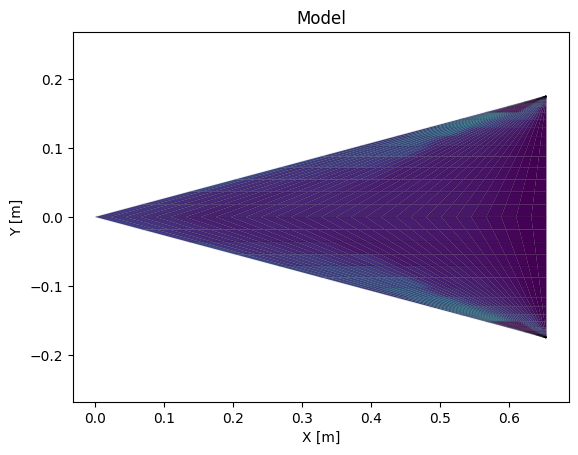

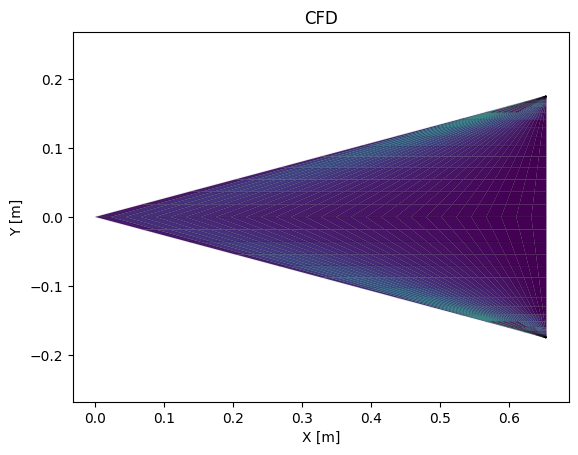

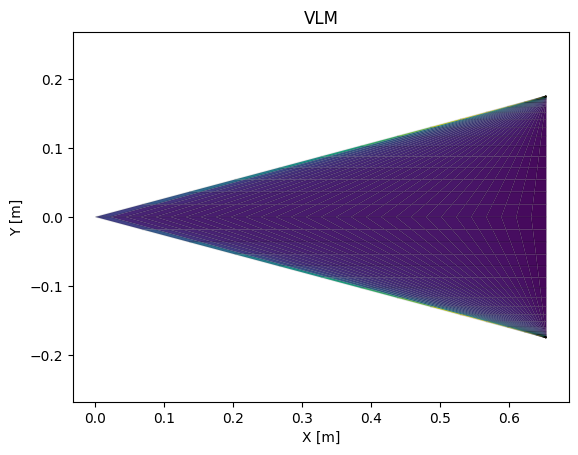

In [10]:
# Evaluate the model on the test set
test_loss = 0
for data in nn_test_set:
    data = data.to(device)
    with torch.no_grad():
        output = model(data)
        test_loss += F.mse_loss(output, data.y).item()

test_loss /= len(test_set)
print(f'Test loss: {test_loss:.4f}')
# Plot the results for a random index
test_index = np.random.randint(len(test_set))
data = nn_test_set[test_index].to(device)

# evaluate the model 
with torch.no_grad():
    output = model(data).cpu().numpy().reshape(-1)
    print(output.shape)
    print(f"Test {test_index} Predicted, AoA: {test_set[test_index].alpha}, Mach: {test_set[test_index].mach} dcp")
    plot_field_distribution(test_set[test_index].vlm_vd, np.array(output), 
                            title=f"Model", cbar=True,
                            min=0, max=2)
    plot_field_distribution(test_set[test_index].vlm_vd, np.array(test_set[test_index].cfd_data),
                            title=f"CFD", cbar=True,
                            min=0, max=2)
    plot_field_distribution(test_set[test_index].vlm_vd, np.array(test_set[test_index].vlm_data),
                            title=f"VLM", cbar=True,
                            min=0, max=2)
    print(f"Re: {test_set[test_index].Re:.2e}")

Record and compare the field prediction quality for the entire set

In [11]:
from sklearn.metrics import r2_score

nn_total_set = nn_training_set + nn_test_set
total_set = train_set + test_set

# Calculate the MSE and R2 for the training set
train_loss = 0
train_targets = []
train_predictions = []

# Iterate over the set and collect predictions and targets
for data in nn_training_set:
    data = data.to(device)
    with torch.no_grad():
        output = model(data)
        train_predictions.append(output.cpu().numpy())
        train_targets.append(data.y.cpu().numpy())
        train_loss += F.mse_loss(output, data.y).item()

train_loss /= len(nn_training_set)
train_targets = np.concatenate(train_targets, axis=0)
train_predictions = np.concatenate(train_predictions, axis=0)
train_r2 = r2_score(train_targets, train_predictions)

# Calculate the MSE and R2 for the test set
test_loss = 0
test_targets = []
test_predictions = []

for data in nn_test_set:
    data = data.to(device)
    with torch.no_grad():
        output = model(data)
        test_predictions.append(output.cpu().numpy())
        test_targets.append(data.y.cpu().numpy())
        test_loss += F.mse_loss(output, data.y).item()

test_loss /= len(nn_test_set)
test_targets = np.concatenate(test_targets, axis=0)
test_predictions = np.concatenate(test_predictions, axis=0)
test_r2 = r2_score(test_targets, test_predictions)

# Calculate the MSE and R2 for the entire dataset
total_loss = 0
total_targets = []
total_predictions = []

for data in nn_total_set:
    data = data.to(device)
    with torch.no_grad():
        output = model(data)
        total_predictions.append(output.cpu().numpy())
        total_targets.append(data.y.cpu().numpy())
        total_loss += F.mse_loss(output, data.y).item()

total_loss /= len(nn_total_set)
total_targets = np.concatenate(total_targets, axis=0)
total_predictions = np.concatenate(total_predictions, axis=0)
total_r2 = r2_score(total_targets, total_predictions)

# Print results
print(f'Training loss (MSE): {train_loss:.4f}, R2: {train_r2:.4f}')
print(f'Test loss (MSE): {test_loss:.4f}, R2: {test_r2:.4f}')
print(f'Total loss (MSE): {total_loss:.4f}, R2: {total_r2:.4f}')




Training loss (MSE): 0.0377, R2: 0.8382
Test loss (MSE): 0.0369, R2: 0.8410
Total loss (MSE): 0.0374, R2: 0.8391


# access the latent infor in the network.

Extract nodal features after a convolutional layer, reduce dimensions using t-SNE, cluster nodes via K-means, and ablate by zeroing non-cluster features. Propagate modified graphs through subsequent layers to observe prediction changes, revealing each cluster's contribution and multi-hop convolution effects on model output.


Test index: 22
Original Reconstruction Error: 0.0315
Modified Reconstruction Error: 0.1771
Test 22 Predicted, with truncated latent layer 0 cluster 0 dcp
Original Reconstruction Error: 0.0315
Modified Reconstruction Error: 0.1763
Test 22 Predicted, with truncated latent layer 0 cluster 1 dcp
Original Reconstruction Error: 0.0315
Modified Reconstruction Error: 0.1634
Test 22 Predicted, with truncated latent layer 0 cluster 2 dcp
Original Reconstruction Error: 0.0315
Modified Reconstruction Error: 0.0528
Test 22 Predicted, with truncated latent layer 0 cluster 3 dcp
Original Reconstruction Error: 0.0315
Modified Reconstruction Error: 0.2369
Test 22 Predicted, with truncated latent layer 1 cluster 0 dcp
Original Reconstruction Error: 0.0315
Modified Reconstruction Error: 0.2347
Test 22 Predicted, with truncated latent layer 1 cluster 1 dcp
Original Reconstruction Error: 0.0315
Modified Reconstruction Error: 0.2288
Test 22 Predicted, with truncated latent layer 1 cluster 2 dcp
Original Rec

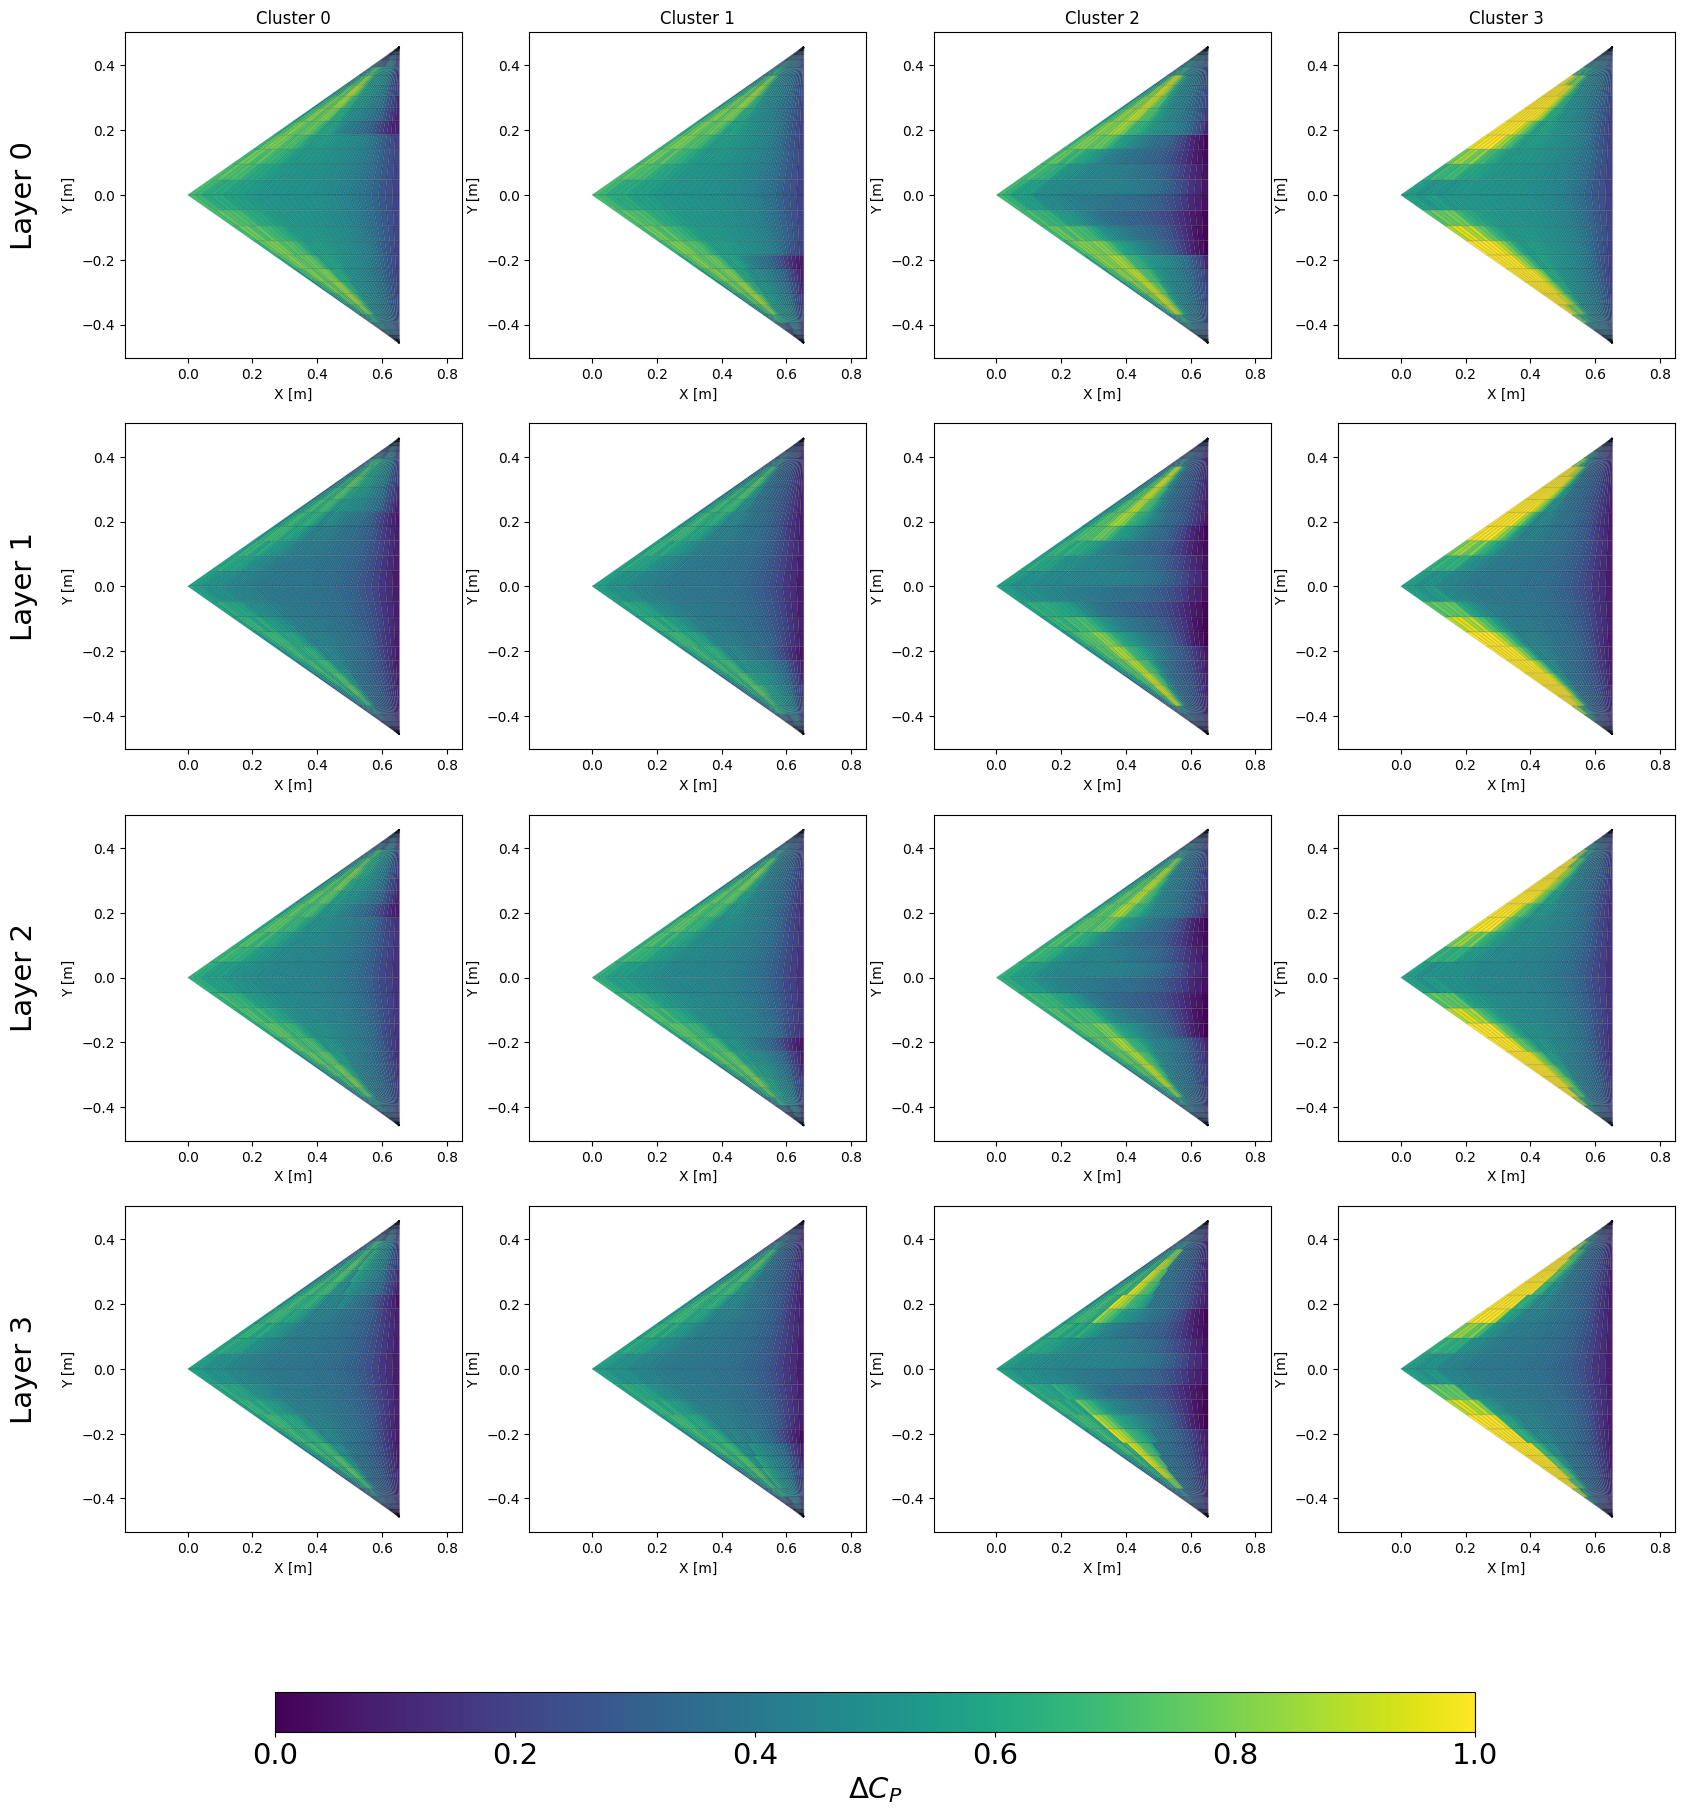

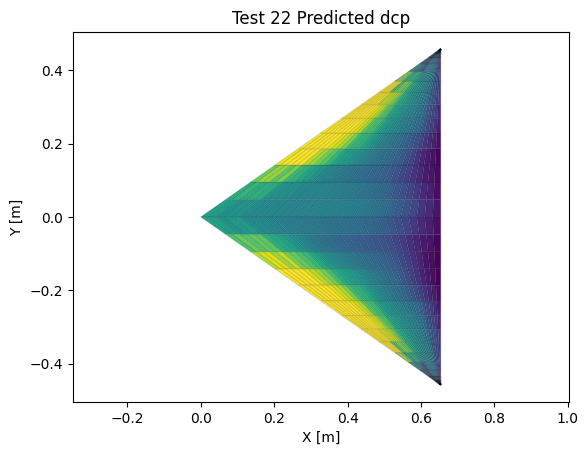

In [12]:
# Modified Code
import plotly.express as px
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE

# configurations
tsne_components = 2  # Reduce to 2D for clustering
tsne_perplexity = 30  # Trade-off parameter for t-SNE
tsne_random_state = 42  # Ensure reproducibility

# specify a specific run
test_index = 22
print(f"Test index: {test_index}")
data = nn_test_set[test_index].to(device)

# evaluate the model prediction
model.eval()
with torch.no_grad():
    original_output, latent_representations = model(data, return_latent_space=True)

# specify number of clusters 
num_clusters = 4

# initialize the output
cluster_indices_first_layer = None  # To store cluster indices for the first layer
difference_storage = []
difference_x_label = []


fig, axes = plt.subplots(len(latent_representations), num_clusters, figsize=(20, 5 * len(latent_representations)), constrained_layout=True)
fig.subplots_adjust(bottom=0.15, top=0.90, hspace=0.2, wspace=0.2)  
cbar_ax = fig.add_axes([0.2, 0.05, 0.6, 0.02])  

# Add labels for layer indices on the left
for ilayer in range(len(latent_representations)):
    axes[ilayer, 0].annotate(f"Layer {ilayer}",
                             xy=(-0.3, 0.5), xycoords="axes fraction",
                             fontsize=21, ha="center", va="center", rotation=90)

# Iterate over each layer of the latent representations
for ilayer in range(len(latent_representations)):
    layer_to_modify = ilayer
    latent = latent_representations[layer_to_modify]

    latent_np = latent.cpu().numpy()
    
    if ilayer == 0:
        # Perform t-SNE dimensionality reduction
        tsne = TSNE(n_components=tsne_components, perplexity=tsne_perplexity, random_state=tsne_random_state)
        latent_tsne = tsne.fit_transform(latent_np)

        # Apply KMeans clustering on the t-SNE result
        kmeans = KMeans(n_clusters=num_clusters, random_state=42)
        clusters = kmeans.fit_predict(latent_tsne)

        # Store cluster indices for the first layer
        cluster_indices_first_layer = clusters
    else:
        # Use cluster indices from the first layer
        clusters = cluster_indices_first_layer

    for icluster in range(num_clusters):
        # Isolate desired clusters based on first-layer indices
        cluster_mask = np.isin(clusters, icluster).astype(np.float32)
        cluster_mask = torch.tensor(cluster_mask, device=latent.device, dtype=latent.dtype).unsqueeze(1)

        if ilayer > 0:
            # Only keep weights corresponding to the current cluster
            layer_weights = latent.clone()
            layer_weights[~cluster_mask.bool().flatten()] = 0
            modified_latent = layer_weights
        else:
            # For the first layer, use the cluster mask directly
            modified_latent = latent * cluster_mask

        # Pass the modified latent representation through the model
        with torch.no_grad():
            modified_output = model(data, modify_latent=True, layer_to_modify=layer_to_modify, modified_latent=modified_latent)

        original_error = torch.mean((data.y - original_output) ** 2).item()
        modified_error = torch.mean((data.y - modified_output) ** 2).item()

        print(f"Original Reconstruction Error: {original_error:.4f}")
        print(f"Modified Reconstruction Error: {modified_error:.4f}")

        # Visualize differences
        original_output_np = original_output.cpu().numpy()
        modified_output_np = modified_output.cpu().numpy()
        difference = np.abs(modified_output_np - original_output_np) / np.abs(original_output_np)

        difference_storage.append(difference)
        difference_x_label.append(10 * ilayer + icluster) # for error specturm plot

        # Plot field distribution
        print(f"Test {test_index} Predicted, with truncated latent layer {ilayer} cluster {icluster} dcp")
        modified_output_np = modified_output.cpu().numpy().reshape(-1)

        # Plot using plot_field_distribution
        ax = axes[ilayer, icluster]
        title_string = f"Cluster {icluster}" if ilayer == 0 else ""
        scalar_map = plot_field_distribution(test_set[test_index].vlm_vd, modified_output_np,
                                             title=title_string,
                                             min=0, max=1.5, ax=ax)

# Add the shared color bar
cbar = fig.colorbar(scalar_map, cax=cbar_ax, orientation="horizontal")
cbar.ax.tick_params(labelsize=21)  
cbar.set_label("$\Delta C_P$", fontsize=21)

# Display the plot
plt.show()

# Plot unmodified output
plot_field_distribution(test_set[test_index].vlm_vd, np.array(original_output.cpu().numpy().reshape(-1)), 
                        title=f"Test {test_index} Predicted dcp",
                        min=0, max=1.5)

# Plot all differences
difference_storage_array = np.array(difference_storage).reshape(900, num_clusters * len(latent_representations))

fig = px.imshow(
    difference_storage_array,
    labels={'x': 'Latent Layer (HOP, Cluster)', 'y': 'Lattice Index', 'color': 'Relative Error'},
    x=[f'{x:02}' for x in difference_x_label],  # Format x-axis labels as two-digit
    y=np.arange(difference_storage_array.shape[0]),  # Automatically label the y-axis based on array shape
    color_continuous_scale='Viridis',
    aspect="auto",
    zmin=0,
    zmax=2
)
fig.update_traces(zmin=0, zmax=2)
fig.update_layout(
    title="Latent Layer Impact on Prediction Error",
    width=800,  # Adjust dimensions if needed
    height=600
)
fig.show()


